In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
df.shape

(162980, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [5]:
df['category'].value_counts()

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

In [6]:
df.isnull().sum()

clean_text    4
category      7
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

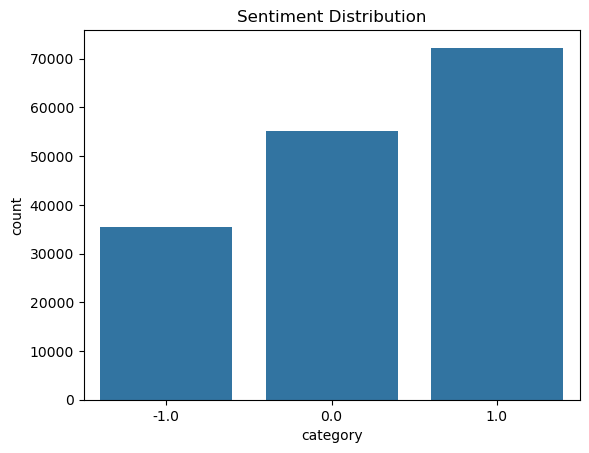

In [9]:
sns.countplot(
    x='category',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [10]:
df['category'] = df['category'].replace({
    -1:'Negative',
     0:'Neutral',
     1:'Positive'
})

In [11]:
import re

def preprocess(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

df['clean_text'] = df['clean_text'].apply(preprocess)

In [12]:
vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    df['clean_text']
)

y = df['category']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
predictions = model.predict(
    X_test
)

In [16]:
accuracy_score(
    y_test,
    predictions
)

0.737467018469657

In [17]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.42      0.57      7152
     Neutral       0.88      0.67      0.76     11067
    Positive       0.65      0.95      0.78     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



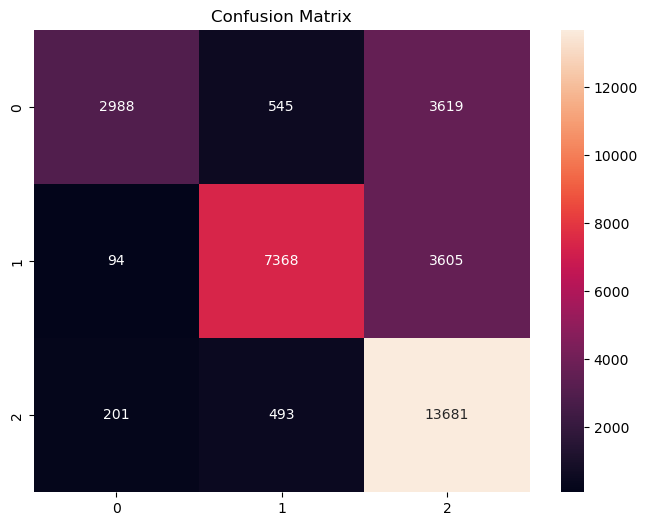

In [18]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [19]:
from collections import Counter

positive = " ".join(
    df[df['category']=='Positive']
    ['clean_text']
)

Counter(
    positive.split()
).most_common(20)

[('modi', 70520),
 ('the', 53329),
 ('and', 34566),
 ('for', 26651),
 ('you', 19426),
 ('india', 16087),
 ('that', 14475),
 ('will', 14430),
 ('are', 14214),
 ('this', 14074),
 ('not', 13546),
 ('with', 10575),
 ('has', 10080),
 ('have', 10027),
 ('but', 9462),
 ('all', 9136),
 ('his', 8189),
 ('was', 7937),
 ('from', 7783),
 ('they', 7149)]

In [20]:
sample = [
    "This product is amazing and I love it"
]

sample_vector = vectorizer.transform(
    sample
)

model.predict(sample_vector)

array(['Positive'], dtype='<U8')